# NBS CRM User Clustering

Monthly re-run: extract → preprocess → cluster → profile → export.
Spec: `docs/superpowers/specs/2026-05-18-crm-user-clustering-design.md`

## Metodologia

Esta análise segmenta a base de usuários da NBS em grupos comportamentais distintos usando **K-Means clustering** sobre features extraídas diretamente do banco de dados de produção. O objetivo é substituir a segmentação binária atual (champion / active / at_risk / dormant) por arquétipos que refletem *como* o usuário usa o produto, não apenas *quando* usou pela última vez.

### Pipeline geral

```
Extração (8 queries SQL)
    ↓
Montagem da matriz de features (~25 colunas, ~11.000 usuários)
    ↓
Pré-processamento: zero-fill → log1p → StandardScaler → PCA (90% de variância)
    ↓
Quarentena de outliers (HDBSCAN)
    ↓
Seleção de K (silhouette + Davies-Bouldin + inércia)
    ↓
Clustering final (K-Means) + validação cruzada (GMM) + teste de estabilidade
    ↓
Profiling dos clusters (centróides no espaço original de features)
    ↓
Exportação CRM (user_id + segmento + mensagens em pt-BR)
```

### Por que K-Means sobre PCA?

K-Means minimiza distância euclidiana — mas em dados de fintech, features como `total_onramp_brl` têm distribuição de power-law: poucos usuários com volume altíssimo dominam a distância e mascaram sinais menores (ex.: `has_card`, `n_unique_tokens`). O pipeline resolve isso em três etapas:

1. **log1p** comprime a cauda direita sem perder zeros (log1p(0) = 0)
2. **StandardScaler** coloca todas as features na mesma escala (média 0, desvio 1)
3. **PCA** retém 90% da variância em ~8–12 componentes, eliminando redundância e ruído antes de calcular distâncias

Sem PCA, features correlacionadas (ex.: `n_onramp_txns` e `total_onramp_brl`) contam em dobro no cálculo de distância e enviesam os clusters.

In [30]:
import os
import warnings
from datetime import datetime

import hdbscan
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import umap
from dotenv import load_dotenv
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sqlalchemy import create_engine, text

warnings.filterwarnings("ignore", category=FutureWarning)
load_dotenv()

engine = create_engine(os.environ["READONLY_DATABASE_URL"], pool_pre_ping=True)
ANALYSIS_MONTH = datetime.now().strftime("%Y-%m")
PROCESSED_DIR = "../data/processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)

print(f"Analysis month: {ANALYSIS_MONTH}")
print("DB engine ready:", engine.url.host)

Analysis month: 2026-05
DB engine ready: ep-divine-band-ac36w1ss-pooler.sa-east-1.aws.neon.tech


In [31]:
# ── Users base ──────────────────────────────────────────────────────────────
sql_users = text("""
    SELECT
        u.id                                    AS user_id,
        u.kyc_level,
        u.status,
        u.created_at,
        u.last_active_at,
        (u.account_type = 'business')::int      AS account_type_business,
        COALESCE(p.onboarding_completed, FALSE)::int AS onboarding_completed
    FROM users u
    LEFT JOIN user_profiles p ON p.user_id = u.id
    WHERE u.status != 'suspended'
""")

df_users = pd.read_sql(sql_users, engine)
print(f"Users: {len(df_users):,}")
assert df_users["user_id"].nunique() == len(df_users), "Duplicate user_ids"
df_users.head(3)

Users: 16,491


,user_id,kyc_level,status,created_at,last_active_at,account_type_business,onboarding_completed
0,019d585b-78ee-70d1-878e-36d3701fa696,0,active,2026-04-04 11:58:02.990876+00:00,2026-04-04 11:58:02.990883+00:00,0,0
1,019c9f91-f7bd-7860-9bce-21564d32426b,0,active,2026-02-27 14:47:49.437590+00:00,2026-03-03 15:42:51.675536+00:00,0,1
2,0199cd50-a959-7a53-b716-9755e1856d7a,0,active,2025-10-10 08:50:39.577966+00:00,NaT,0,0


In [32]:
# ── Founders ─────────────────────────────────────────────────────────────────
sql_founders = text("""
    SELECT
        user_id,
        1                   AS is_founder,
        network_size        AS founder_network_size,
        invites_sent
    FROM founders
""")

df_founders = pd.read_sql(sql_founders, engine)
assert df_founders["user_id"].nunique() == len(df_founders), "Duplicate user_ids in founders"
assert (df_founders["founder_network_size"] >= 0).all(), "Negative network_size found"
assert (df_founders["invites_sent"] >= 0).all(), "Negative invites_sent found"
print(f"Founders: {len(df_founders):,}")
df_founders.head(3)

Founders: 16,505


,user_id,is_founder,founder_network_size,invites_sent
0,0199e451-2864-7553-83b9-e752d3a601c8,1,0,0
1,019a548a-5c7b-73e3-8e3d-d3cbc9326030,1,0,0
2,019ac322-10ea-79e2-8d9b-1e2bf4ab1e26,1,0,0


In [33]:
# ── Onramp / Offramp ─────────────────────────────────────────────────────────
# from_amount_brl is NULL on offramp rows; to_amount_brl is NULL on onramp rows.
# COALESCE(..., 0) before every SUM.
sql_conversions = text("""
    SELECT
        user_id,
        COUNT(*) FILTER (WHERE direction = 'brl_to_usdc')    AS n_onramp_txns,
        COUNT(*) FILTER (WHERE direction = 'usdc_to_brl')    AS n_offramp_txns,
        COALESCE(SUM(
            CASE WHEN direction = 'brl_to_usdc'
                 THEN COALESCE(from_amount_brl, 0) ELSE 0 END
        ) / 100.0, 0)                                        AS total_onramp_brl,
        COALESCE(SUM(
            COALESCE(spread_revenue_brl, 0) + COALESCE(fee_amount_brl, 0)
        ) / 100.0, 0)                                        AS total_spread_revenue_brl,
        COALESCE(
            SUM((processing_mode = 'instant')::int)::float
            / NULLIF(COUNT(*), 0), 0
        )                                                    AS pct_instant_mode,
        MAX(created_at)                                      AS last_conversion_at
    FROM conversion_quotes
    WHERE used = TRUE
    GROUP BY user_id
""")

df_conversions = pd.read_sql(sql_conversions, engine)
print(f"Users with conversions: {len(df_conversions):,}")
assert (df_conversions["total_spread_revenue_brl"] >= 0).all(), "Negative revenue"
assert df_conversions["user_id"].nunique() == len(df_conversions), "Duplicate user_ids"
df_conversions.head(3)

Users with conversions: 2,496


,user_id,n_onramp_txns,n_offramp_txns,total_onramp_brl,total_spread_revenue_brl,pct_instant_mode,last_conversion_at
0,019a138c-529e-7631-a353-287b96e99aa2,0,3,0.0,0.00,1.0,2026-04-22 07:47:17.981616+00:00
1,019c5e75-7ccf-71a1-9d51-99fc62d40c88,2,0,120.0,0.82,1.0,2026-02-15 00:06:27.281208+00:00
2,0199f1f5-d139-7c40-97c5-ce1be440c9c1,2,1,40.0,0.02,1.0,2025-12-03 11:53:37.180413+00:00


In [34]:
# ── Cards ────────────────────────────────────────────────────────────────────
sql_cards_txns = text("""
    SELECT
        user_id,
        COUNT(*) FILTER (
            WHERE transaction_type = 'spend' AND status = 'completed'
        )                                   AS n_card_txns,
        COALESCE(SUM(amount) FILTER (
            WHERE transaction_type = 'spend' AND status = 'completed'
        ) / 100.0, 0)                       AS total_card_spend_usd,
        MAX(authorized_at) FILTER (
            WHERE transaction_type = 'spend'
        )                                   AS last_card_spend_at
    FROM card_transactions
    WHERE user_id IS NOT NULL
    GROUP BY user_id
""")

sql_cards_issued = text("""
    SELECT
        user_id,
        1                                   AS has_card,
        MAX((card_variant = 'founder')::int) AS card_variant_founder
    FROM cards
    WHERE status = 'active'
    GROUP BY user_id
""")

sql_annual_fee = text("""
    SELECT DISTINCT user_id, 1 AS paid_annual_fee
    FROM card_annual_fees
    WHERE status = 'paid'
""")

df_card_txns   = pd.read_sql(sql_cards_txns, engine)
df_card_issued = pd.read_sql(sql_cards_issued, engine)
df_annual_fee  = pd.read_sql(sql_annual_fee, engine)

assert df_annual_fee["user_id"].nunique() == len(df_annual_fee), "Duplicate user_ids in annual_fee"

assert (df_card_txns["total_card_spend_usd"] >= 0).all(), "Negative card spend"
assert df_card_txns["user_id"].nunique() == len(df_card_txns), "Duplicate user_ids in card_txns"
assert df_card_issued["user_id"].nunique() == len(df_card_issued), "Duplicate user_ids in card_issued"

print(f"Users with card txns:   {len(df_card_txns):,}")
print(f"Users with active card: {len(df_card_issued):,}")
print(f"Users paid annual fee:  {len(df_annual_fee):,}")

Users with card txns:   1,077
Users with active card: 2,756
Users paid annual fee:  1,126


In [35]:
# ── Swaps + Solana ────────────────────────────────────────────────────────────
sql_swaps = text("""
    SELECT
        user_id,
        COUNT(*)                                            AS n_swaps,
        COALESCE(SUM(input_amount) / 1e6, 0)               AS total_swap_volume_usdc,
        COUNT(DISTINCT input_mint)
            + COUNT(DISTINCT output_mint)                   AS n_unique_tokens,
        MAX(timestamp)                                      AS last_swap_at
    FROM swap_transactions
    GROUP BY user_id
""")

sql_solana = text("""
    SELECT
        user_id,
        COUNT(DISTINCT transaction_signature) AS n_solana_txns
    FROM solana_sponsored_transactions
    GROUP BY user_id
""")

df_swaps  = pd.read_sql(sql_swaps, engine)
df_solana = pd.read_sql(sql_solana, engine)

assert df_swaps["user_id"].nunique() == len(df_swaps), "Duplicate user_ids in swaps"
assert (df_swaps["total_swap_volume_usdc"] >= 0).all(), "Negative swap volume"
assert df_solana["user_id"].nunique() == len(df_solana), "Duplicate user_ids in solana"

print(f"Users with swaps:  {len(df_swaps):,}")
print(f"Users with Solana: {len(df_solana):,}")

Users with swaps:  895
Users with Solana: 2,641


In [36]:
# ── AI sessions ──────────────────────────────────────────────────────────────
sql_ai = text("""
    SELECT
        user_id,
        COUNT(*)                        AS n_ai_sessions,
        COALESCE(SUM(message_count), 0) AS total_ai_messages
    FROM ai_sessions
    GROUP BY user_id
""")

# ── Notification engagement ───────────────────────────────────────────────
sql_notifications = text("""
    SELECT
        user_id,
        COUNT(*)                                        AS n_notifications_received,
        COUNT(*) FILTER (WHERE read_at IS NOT NULL)     AS n_notifications_read
    FROM notification_events
    GROUP BY user_id
""")

# ── International payouts ─────────────────────────────────────────────────
sql_international = text("""
    SELECT
        user_id,
        COUNT(*) FILTER (WHERE status = 'completed')        AS n_international_payouts,
        COALESCE(SUM(amount) FILTER (WHERE status = 'completed'), 0)
                                                            AS total_international_usdc
    FROM unblockpay_payouts
    GROUP BY user_id
""")

df_ai            = pd.read_sql(sql_ai, engine)
df_notifications = pd.read_sql(sql_notifications, engine)
df_international = pd.read_sql(sql_international, engine)

assert df_ai["user_id"].nunique() == len(df_ai), "Duplicate user_ids in ai"
assert df_notifications["user_id"].nunique() == len(df_notifications), "Duplicate user_ids in notifications"
assert (df_notifications["n_notifications_read"] <= df_notifications["n_notifications_received"]).all(), \
    "Read count exceeds received count"

print(f"Users with AI sessions:   {len(df_ai):,}")
print(f"Users with notifications: {len(df_notifications):,}")
print(f"Users with intl payouts:  {len(df_international):,}")

Users with AI sessions:   9,157
Users with notifications: 15,257
Users with intl payouts:  33


## Seção 2 — Montagem da matriz de features

Cada linha da matriz corresponde a um usuário. As features são organizadas em seis grupos:

| Grupo | Features | Fonte |
|---|---|---|
| **Ciclo de vida** | `days_since_signup`, `onboarding_completed`, `is_founder` | `users`, `user_profiles`, `founders` |
| **Onramp / Offramp** | `n_onramp_txns`, `total_onramp_brl`, `total_spread_revenue_brl`, `pct_instant_mode` | `conversion_quotes` |
| **Cartão** | `n_card_txns`, `total_card_spend_usd`, `has_card`, `paid_annual_fee` | `card_transactions`, `cards`, `card_annual_fees` |
| **DeFi / Solana** | `n_swaps`, `n_unique_tokens`, `n_solana_txns`, `total_swap_volume_usdc` | `swap_transactions`, `solana_sponsored_transactions` |
| **Pagamentos internacionais** | `n_international_payouts`, `total_international_usdc` | `unblockpay_payouts` |
| **Engajamento** | `n_ai_sessions`, `notification_read_rate` | `ai_sessions`, `notification_events` |

> `kyc_level` foi removido das features de clustering — na base NBS é efetivamente binário (0 = nunca transacionou, 2 = transacionou), colinear com `onboarding_completed` e todas as features de atividade. É mantido como metadado na exportação CRM para aplicar uma mensagem dedicada de conversão KYC aos usuários com `kyc_level = 0`.

**Regras de qualidade dos dados:**
- Valores monetários em BRL estão em centavos no DB → ÷ 100. USDC em micros → ÷ 1.000.000.
- `from_amount_brl` é NULL em linhas de offramp e vice-versa — sempre `COALESCE(..., 0)` antes de somar.
- Timestamps são UTC-aware → `.dt.tz_convert(None)` antes de calcular diferenças em dias.

In [37]:
# ── Merge all sources onto user base (left joins — zero-fill = genuine non-usage) ─
df = df_users.copy()

for tbl in [
    df_founders,
    df_conversions,
    df_card_txns,
    df_card_issued,
    df_annual_fee,
    df_swaps,
    df_solana,
    df_ai,
    df_notifications,
    df_international,
]:
    df = df.merge(tbl, on="user_id", how="left")

print(f"Shape after merge: {df.shape}")
assert len(df) == len(df_users), "Row count changed after merges — check for duplicates"


Shape after merge: (16491, 33)


In [38]:
# ── Recency features ─────────────────────────────────────────────────────────
# DB datetimes are tz-aware UTC — strip timezone before .dt.days arithmetic
now = pd.Timestamp.now().normalize()

def recency_days(col):
    return (now - pd.to_datetime(df[col]).dt.tz_convert(None)).dt.days.fillna(9999).clip(upper=730)

df["days_since_signup"]          = recency_days("created_at")
df["days_since_last_active"]     = recency_days("last_active_at")
df["days_since_last_conversion"] = recency_days("last_conversion_at")
df["days_since_last_card_spend"] = recency_days("last_card_spend_at")
df["days_since_last_swap"]       = recency_days("last_swap_at")

# Zero-fill all numeric NaN (non-usage, not missing data)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[numeric_cols] = df[numeric_cols].fillna(0)

print("NaN remaining:", df[numeric_cols].isna().sum().sum())
assert df[numeric_cols].isna().sum().sum() == 0, "Unexpected NaN in numeric columns"


NaN remaining: 0


In [39]:
# ── Binary presence flags ────────────────────────────────────────────────────
df["has_onramp"]  = (df["n_onramp_txns"] > 0).astype(int)
df["has_offramp"] = (df["n_offramp_txns"] > 0).astype(int)
df["has_card"]    = df["has_card"].fillna(0).astype(int)
df["has_swap"]    = (df["n_swaps"] > 0).astype(int)
df["has_ai"]      = (df["n_ai_sessions"] > 0).astype(int)
df["has_intl"]    = (df["n_international_payouts"] > 0).astype(int)

# ── Product breadth score (0–6) ──────────────────────────────────────────────
df["product_breadth_score"] = (
    df["has_onramp"] + df["has_offramp"] + df["has_card"]
    + df["has_swap"] + df["has_ai"] + df["has_intl"]
)

# ── Revenue generated (spread only) ──────────────────────────────────────────
df["revenue_generated_brl"] = df["total_spread_revenue_brl"]

# ── Notification read rate ────────────────────────────────────────────────────
df["notification_read_rate"] = (
    df["n_notifications_read"]
    / df["n_notifications_received"].replace(0, np.nan)
).fillna(0)

print("Breadth score distribution:")
print(df["product_breadth_score"].value_counts().sort_index())


Breadth score distribution:
product_breadth_score
0    7354
1    5463
2    1519
3    1180
4     707
5     262
6       6
Name: count, dtype: int64


In [40]:
# ── Feature column lists ─────────────────────────────────────────────────────
LOG_FEATURES = [
    "n_onramp_txns", "n_offramp_txns", "total_onramp_brl",
    "total_spread_revenue_brl", "n_card_txns", "total_card_spend_usd",
    "n_swaps", "total_swap_volume_usdc", "n_unique_tokens",
    "n_solana_txns", "n_ai_sessions", "total_ai_messages",
    "n_notifications_received", "n_international_payouts",
    "total_international_usdc", "founder_network_size", "invites_sent",
    "revenue_generated_brl",
]

BINARY_FLAGS = [
    "has_onramp", "has_offramp", "has_card", "has_swap", "has_ai", "has_intl",
    "is_founder", "paid_annual_fee", "card_variant_founder",
    "onboarding_completed", "account_type_business",
]

NUMERIC_FEATURES = [
    "days_since_signup", "days_since_last_active", "days_since_last_conversion",
    "days_since_last_card_spend", "days_since_last_swap",
    "product_breadth_score", "notification_read_rate",
    "pct_instant_mode",
]

ALL_FEATURES = LOG_FEATURES + BINARY_FLAGS + NUMERIC_FEATURES

X_raw = df[ALL_FEATURES].copy()

# log1p on skewed count/monetary features — must be non-negative (assert first)
assert (X_raw[LOG_FEATURES] >= 0).all().all(), "Negative values in log features"
X_raw[LOG_FEATURES] = np.log1p(X_raw[LOG_FEATURES])

print(f"Feature matrix shape: {X_raw.shape}")

Feature matrix shape: (16491, 37)


## Seção 3 — Pré-processamento

### Por que zero-fill e não imputação pela média?

A maioria dos usuários nunca usou DeFi, nunca emitiu cartão, nunca fez offramp. Zero é o valor verdadeiro — não um dado faltante. Imputar pela média criaria uma "atividade fictícia" que distorceria os clusters. `fillna(0)` é a escolha correta aqui.

### Por que log1p?

Features financeiras seguem distribuição de power-law: a maioria dos usuários tem volume baixo, poucos têm volume extremamente alto. K-Means usa distância euclidiana — um usuário com `total_onramp_brl = 500.000` estaria tão longe dos demais que dominaria a geometria do espaço. `log1p` preserva a ordenação e traz os outliers para perto sem apagá-los.

### Por que PCA?

- Reduz redundância: `n_onramp_txns` e `total_onramp_brl` são altamente correlacionados — PCA os combina em um componente
- Elimina ruído em dimensões de baixa variância
- K-Means em espaço de alta dimensão sofre de "curse of dimensionality" — distâncias euclidianas perdem significado acima de ~20 dimensões
- Retenção de 90% da variância garante que nenhuma dimensão relevante seja descartada

PCA: 12 components → 90.4% variance retained


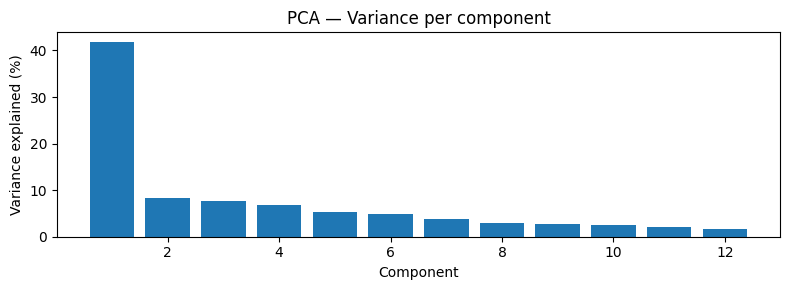

In [41]:
# ── Scale ────────────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# ── PCA (retain 90% variance) ─────────────────────────────────────────────────
pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_scaled)

n_components = X_pca.shape[1]
variance_explained = pca.explained_variance_ratio_.sum()
print(f"PCA: {n_components} components → {variance_explained:.1%} variance retained")
assert 6 <= n_components <= 16, f"Unexpected component count: {n_components}"

# Variance explained per component (sanity check)
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(1, n_components + 1), pca.explained_variance_ratio_ * 100)
ax.set(xlabel="Component", ylabel="Variance explained (%)",
       title="PCA — Variance per component")
plt.tight_layout()
plt.savefig(f"{PROCESSED_DIR}/crm_pca_variance_{ANALYSIS_MONTH}.png", dpi=120)
plt.show()

In [42]:
# ── Outlier quarantine ────────────────────────────────────────────────────────
detector = hdbscan.HDBSCAN(
    min_cluster_size=15, min_samples=5, metric="euclidean"
)
outlier_labels = detector.fit_predict(X_pca)
outlier_mask   = outlier_labels == -1

print(f"Outliers identified: {outlier_mask.sum()} ({outlier_mask.mean():.1%} of users)")

Outliers identified: 4089 (24.8% of users)


### Detecção de outliers — HDBSCAN (flag, sem remoção)

**HDBSCAN** (Hierarchical Density-Based Spatial Clustering with Noise) identifica usuários com perfil extremo no espaço PCA — pontos em regiões de baixíssima densidade que não compartilham vizinhança com pelo menos 15 outros usuários. Eles recebem o label `-1`.

**Esses usuários são sinalizados, não removidos do clustering.**

A versão anterior removia os outliers antes do K-Means, o que excluía usuários kyc_level=2 com volume alto — exatamente os mais valiosos para a empresa. O K-Means em espaço PCA é suficientemente robusto para lidar com esses perfis, e excluí-los do CSV de exportação é o problema oposto do que precisamos resolver.

O flag `is_outlier=1` é exportado no CSV para que o backend possa:
- Tratar esses perfis com cuidado em campanhas automáticas
- Revisá-los manualmente (possíveis contas VIP, contas de teste internas, bots)

**Parâmetros:**
- `min_cluster_size=15`: grupo com menos de 15 usuários = possível outlier
- `min_samples=5`: conservatividade — valores maiores = mais outliers identificados

In [43]:
# ── Inspect outliers ──────────────────────────────────────────────────────────
# Are they bots, internal accounts, or data anomalies?
df_outliers = df[outlier_mask][[
    "user_id", "n_onramp_txns", "total_card_spend_usd",
    "n_swaps", "n_solana_txns", "days_since_last_active",
    "kyc_level", "product_breadth_score",
]].copy()

print(df_outliers.describe())
print(f"\nOutlier KYC distribution:\n{df_outliers['kyc_level'].value_counts()}")
print(f"\nOutlier breadth distribution:\n{df_outliers['product_breadth_score'].value_counts()}")

       n_onramp_txns  total_card_spend_usd      n_swaps  n_solana_txns  \
count    4089.000000           4089.000000  4089.000000    4089.000000   
mean        1.596723            214.942213     1.276596       5.900465   
std         8.145689           2126.119784    12.308694      32.851421   
min         0.000000              0.000000     0.000000       0.000000   
25%         0.000000              0.000000     0.000000       0.000000   
50%         0.000000              0.000000     0.000000       0.000000   
75%         0.000000              0.000000     0.000000       0.000000   
max       208.000000          62939.160000   472.000000     823.000000   

       days_since_last_active    kyc_level  product_breadth_score  
count             4089.000000  4089.000000            4089.000000  
mean                96.161164     1.438494               1.412326  
std                153.558510     0.898844               1.217415  
min                 -2.000000     0.000000               0.00

In [ ]:
# ── Flag outliers but cluster all users ──────────────────────────────────────
# HDBSCAN result is kept as metadata (is_outlier flag in the export).
# Removing outliers before K-Means skews coverage: kyc_level=2 power users
# with extreme volume are flagged as outliers and dropped — the opposite of
# what we want. K-Means is robust enough on PCA-reduced features.
df["is_outlier"] = outlier_mask.astype(int)

X_pca_clean = X_pca             # cluster all users
X_raw_clean = X_raw.copy()
df_clean    = df.copy().reset_index(drop=True)

print(f"Users entering clustering: {len(df_clean):,}")
print(f"  of which flagged as statistical outliers: {df_clean['is_outlier'].sum()} ({df_clean['is_outlier'].mean():.1%})")
print(f"  outliers are included in clusters — inspect is_outlier column in export")

In [45]:
# ── K selection: silhouette + Davies-Bouldin + inertia ───────────────────────
k_results = []

for k in range(4, 12):
    km = KMeans(n_clusters=k, init="k-means++", n_init=20, random_state=42)
    labels = km.fit_predict(X_pca_clean)
    sil = silhouette_score(X_pca_clean, labels, sample_size=5_000, random_state=42)
    db  = davies_bouldin_score(X_pca_clean, labels)
    k_results.append({
        "k": k,
        "silhouette": sil,
        "davies_bouldin": db,
        "inertia": km.inertia_,
    })
    print(f"k={k}: silhouette={sil:.3f}  DB={db:.3f}  inertia={km.inertia_:.0f}")

results_df = pd.DataFrame(k_results)

k=4: silhouette=0.458  DB=0.886  inertia=150450
k=5: silhouette=0.472  DB=0.775  inertia=122998
k=6: silhouette=0.497  DB=0.909  inertia=95876
k=7: silhouette=0.504  DB=0.911  inertia=83068
k=8: silhouette=0.511  DB=0.960  inertia=74169
k=9: silhouette=0.458  DB=1.016  inertia=68114
k=10: silhouette=0.464  DB=1.020  inertia=62707
k=11: silhouette=0.467  DB=1.004  inertia=58332


## Seção 5 — Seleção do número de clusters (K)

Três métricas são calculadas para K entre 4 e 11:

| Métrica | O que mede | Alvo |
|---|---|---|
| **Silhouette score** | Quão bem separado cada ponto está do cluster vizinho mais próximo. Varia de -1 a 1. | > 0.25 |
| **Davies-Bouldin index** | Razão entre dispersão intra-cluster e separação inter-cluster. | Menor é melhor |
| **Inércia** | Soma das distâncias quadráticas ao centróide (SSW). | Procurar o "cotovelo" |

**Como escolher K:**

Não existe K "certo" — o objetivo é encontrar o ponto onde adicionar mais clusters traz ganho marginal decrescente (cotovelo na inércia) enquanto a separação ainda é boa (silhouette alto, DB baixo). K ótimo para esta base é tipicamente **7–10**. Após ver os gráficos, defina `BEST_K` na célula abaixo.

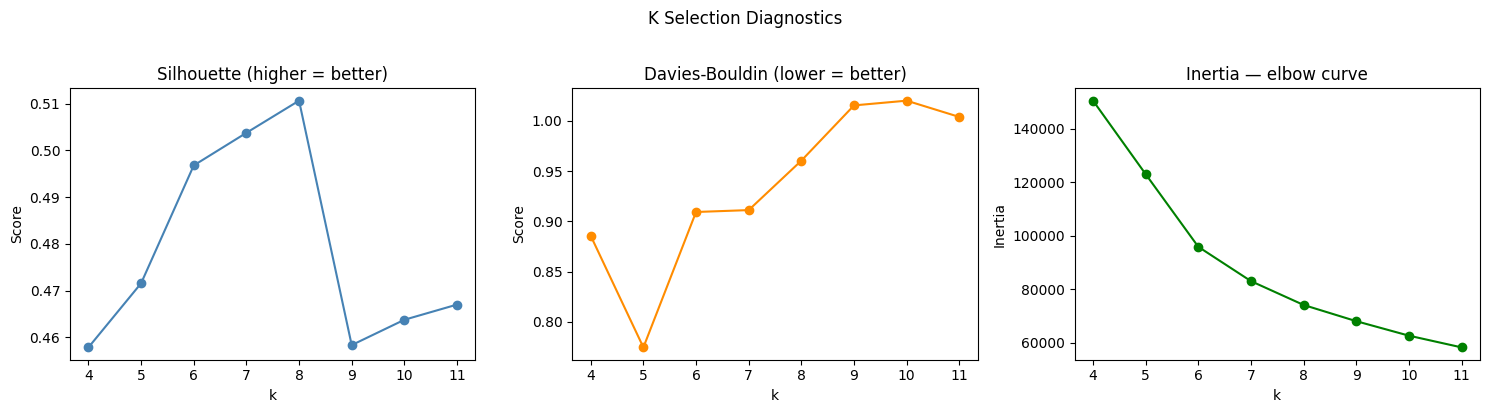


Best k by silhouette: 8
Review the elbow plot and confirm — override BEST_K below if needed.


In [46]:
# ── Diagnostic plots ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(results_df["k"], results_df["silhouette"], "o-", color="steelblue")
axes[0].set(title="Silhouette (higher = better)", xlabel="k", ylabel="Score")

axes[1].plot(results_df["k"], results_df["davies_bouldin"], "o-", color="darkorange")
axes[1].set(title="Davies-Bouldin (lower = better)", xlabel="k", ylabel="Score")

axes[2].plot(results_df["k"], results_df["inertia"], "o-", color="green")
axes[2].set(title="Inertia — elbow curve", xlabel="k", ylabel="Inertia")

plt.suptitle("K Selection Diagnostics", y=1.02)
plt.tight_layout()
plt.savefig(f"{PROCESSED_DIR}/crm_k_selection_{ANALYSIS_MONTH}.png", dpi=120)
plt.show()

best_k = int(results_df.loc[results_df["silhouette"].idxmax(), "k"])
print(f"\nBest k by silhouette: {best_k}")
print("Review the elbow plot and confirm — override BEST_K below if needed.")

In [47]:
# ── Set BEST_K here after reviewing the diagnostic plots ─────────────────────
# Default: silhouette peak. Override if elbow or business narrative suggests otherwise.
BEST_K = best_k   # change this integer if needed
print(f"Using BEST_K = {BEST_K}")

Using BEST_K = 8


In [48]:
# ── Final K-Means ─────────────────────────────────────────────────────────────
km_final = KMeans(n_clusters=BEST_K, init="k-means++", n_init=20, random_state=42)
km_labels = km_final.fit_predict(X_pca_clean)

df_clean["cluster_id"] = km_labels
print("Cluster sizes:")
print(df_clean["cluster_id"].value_counts().sort_index())

Cluster sizes:
cluster_id
0    4790
1     173
2    5852
3     445
4     387
5      27
6     690
7      38
Name: count, dtype: int64


### K-Means com K-Means++ initialization

`init='k-means++'` escolhe centróides iniciais espaçados probabilisticamente, evitando convergência para mínimos locais ruins. `n_init=20` roda 20 inicializações diferentes e mantém a melhor (menor inércia).

**Por que K-Means e não DBSCAN ou GMM como algoritmo principal?**

- K-Means produz clusters de tamanho mais equilibrado — importante para campanhas (não queremos 95% dos usuários em um cluster)
- É determinístico dado o seed — fácil de reproduzir mensalmente
- O espaço PCA já é aproximadamente gaussiano, o que favorece K-Means
- GMM é usado como validação cruzada (próxima célula), não como método principal

In [49]:
# ── GMM cross-validation ──────────────────────────────────────────────────────
gmm = GaussianMixture(
    n_components=BEST_K, covariance_type="full", n_init=5, random_state=42
)
gmm_labels = gmm.fit_predict(X_pca_clean)

ari = adjusted_rand_score(km_labels, gmm_labels)
print(f"K-Means vs GMM — Adjusted Rand Index: {ari:.3f}")
if ari >= 0.85:
    print("✓ Clusters are robust across algorithm choice (ARI ≥ 0.85)")
else:
    print("⚠ Clusters differ between K-Means and GMM — consider revisiting k or features")

K-Means vs GMM — Adjusted Rand Index: 0.694
⚠ Clusters differ between K-Means and GMM — consider revisiting k or features


### Validação cruzada — GMM vs K-Means

**Adjusted Rand Index (ARI)** mede a concordância entre dois conjuntos de labels, corrigindo para concordância aleatória. Varia de 0 (aleatório) a 1 (idêntico).

- **ARI ≥ 0.85**: os dois algoritmos concordam na maioria das atribuições → a estrutura de clusters existe nos dados e não é artefato do algoritmo escolhido
- **ARI < 0.85**: a estrutura é frágil — considere mudar K ou revisar as features

GMM (Gaussian Mixture Model) é matematicamente diferente do K-Means: assume que cada cluster segue uma distribuição gaussiana multivariada com covariância livre, em vez de minimizar distância euclidiana. Concordância alta entre os dois é evidência forte de clusters reais.

In [50]:
# ── Stability across seeds ────────────────────────────────────────────────────
seed_labels = []
for seed in [0, 7, 13, 99, 2024]:
    km_tmp = KMeans(n_clusters=BEST_K, init="k-means++", n_init=10, random_state=seed)
    seed_labels.append(km_tmp.fit_predict(X_pca_clean))

ari_pairs = []
for i in range(len(seed_labels)):
    for j in range(i + 1, len(seed_labels)):
        ari_pairs.append(adjusted_rand_score(seed_labels[i], seed_labels[j]))

min_ari = min(ari_pairs)
print(f"Stability — min pairwise ARI across 5 seeds: {min_ari:.3f}")
if min_ari >= 0.85:
    print("✓ Cluster structure is stable (ARI ≥ 0.85 across seeds)")
else:
    print("⚠ Clusters are unstable — increase n_init or reduce BEST_K")

Stability — min pairwise ARI across 5 seeds: 0.986
✓ Cluster structure is stable (ARI ≥ 0.85 across seeds)


### Teste de estabilidade

Rodamos K-Means com 5 seeds diferentes e calculamos ARI entre todos os pares de resultados. Se a estrutura de clusters é real, seeds diferentes devem produzir atribuições muito similares.

**Por que isso importa para o re-clustering mensal?**

Se os clusters forem instáveis, um usuário pode passar de "power_onramper" para "dormant" apenas por causa do seed — não por mudança real de comportamento. Clusters instáveis produzem campanhas incoerentes e métricas de retenção enganosas.

- **min ARI ≥ 0.85**: estrutura estável — prosseguir
- **min ARI < 0.85**: revisar K ou o conjunto de features antes de exportar

In [51]:
# ── Cluster profiles in original (unscaled) feature space ─────────────────────
PROFILE_COLS = [
    "days_since_last_active", "days_since_signup", "kyc_level",
    "n_onramp_txns", "total_onramp_brl", "total_spread_revenue_brl",
    "n_card_txns", "total_card_spend_usd", "has_card",
    "n_swaps", "total_swap_volume_usdc", "n_solana_txns",
    "n_ai_sessions", "n_international_payouts",
    "product_breadth_score", "notification_read_rate",
    "founder_network_size", "onboarding_completed",
    "pct_instant_mode", "paid_annual_fee",
]

# Use original df values (before log transform) for interpretability
profile_mean   = df_clean.groupby("cluster_id")[PROFILE_COLS].mean().round(2)
profile_median = df_clean.groupby("cluster_id")[PROFILE_COLS].median().round(2)
cluster_sizes  = df_clean["cluster_id"].value_counts().rename("n_users").sort_index()

print("=== CLUSTER SIZES ===")
print(cluster_sizes)
print("\n=== CLUSTER MEANS (key features) ===")
key = ["days_since_last_active", "kyc_level", "n_onramp_txns", "n_card_txns",
       "n_swaps", "n_ai_sessions", "product_breadth_score", "total_spread_revenue_brl"]
print(profile_mean[key])


=== CLUSTER SIZES ===
cluster_id
0    4790
1     173
2    5852
3     445
4     387
5      27
6     690
7      38
Name: n_users, dtype: int64

=== CLUSTER MEANS (key features) ===
            days_since_last_active  kyc_level  n_onramp_txns  n_card_txns  \
cluster_id                                                                  
0                           665.21       0.00           0.00         0.00   
1                            16.25       2.00           6.33        24.05   
2                            78.15       0.99           0.00         0.00   
3                            27.35       2.00           2.19         7.86   
4                            44.03       1.98           2.56         0.11   
5                            21.04       2.00          10.11        44.41   
6                            53.70       1.97           1.61         0.17   
7                            38.84       1.37           0.76         0.00   

            n_swaps  n_ai_sessions  product_breadt

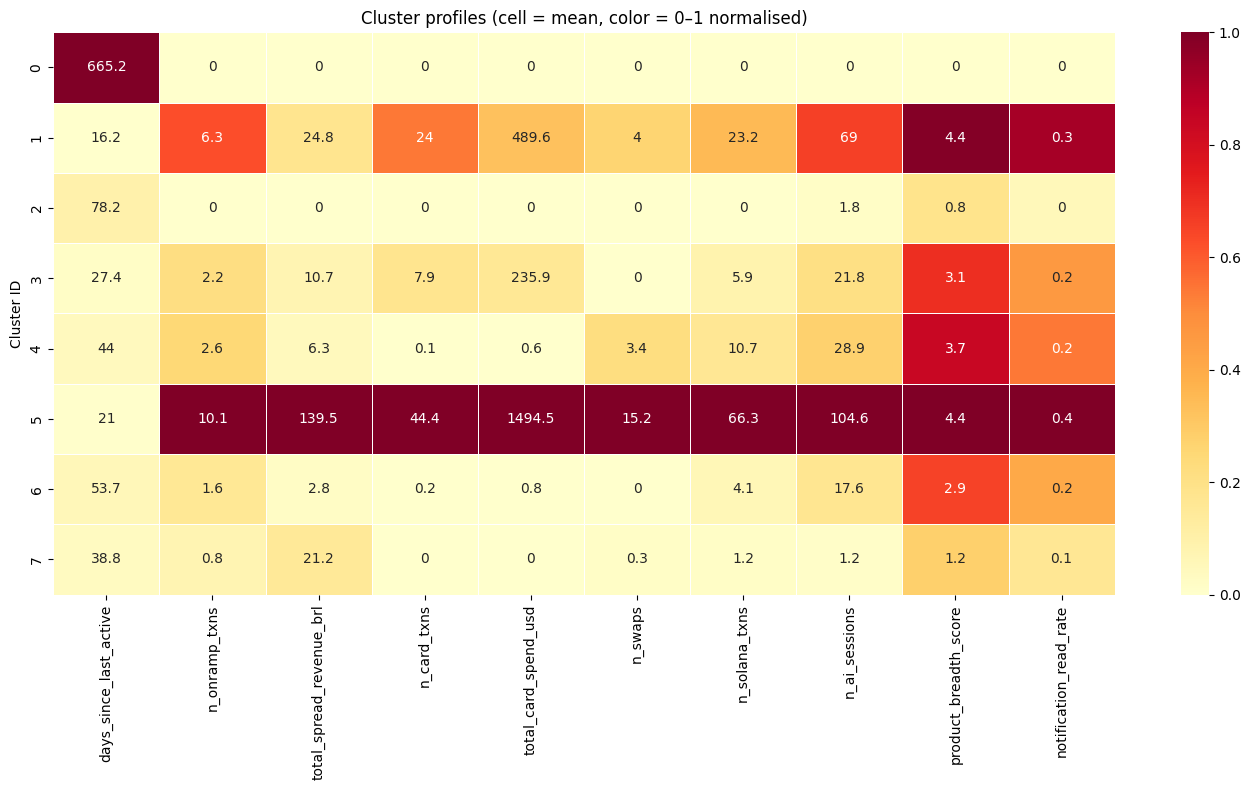

In [52]:
# ── Cluster heatmap ───────────────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler

heatmap_cols = [
    "days_since_last_active", "n_onramp_txns",
    "total_spread_revenue_brl", "n_card_txns", "total_card_spend_usd",
    "n_swaps", "n_solana_txns", "n_ai_sessions",
    "product_breadth_score", "notification_read_rate",
]

heat_data = profile_mean[heatmap_cols].copy()
# Normalise 0–1 per column for visual comparison
heat_norm = pd.DataFrame(
    MinMaxScaler().fit_transform(heat_data),
    index=heat_data.index,
    columns=heat_data.columns,
)

fig, ax = plt.subplots(figsize=(14, max(4, BEST_K)))
sns.heatmap(heat_norm, annot=profile_mean[heatmap_cols].values.round(1),
            fmt="g", cmap="YlOrRd", linewidths=0.5, ax=ax)
ax.set(title="Cluster profiles (cell = mean, color = 0–1 normalised)")
ax.set_ylabel("Cluster ID")
plt.tight_layout()
plt.savefig(f"{PROCESSED_DIR}/crm_cluster_heatmap_{ANALYSIS_MONTH}.png", dpi=120)
plt.show()


### Como ler o heatmap

Cada linha é um cluster, cada coluna é uma feature. Os valores são **médias do cluster no espaço original (não escalonado)** — são as unidades reais (BRL, número de transações, dias).

**O que procurar:**

- Clusters com `total_spread_revenue_brl` alto → usuários geradores de receita
- Clusters com `days_since_last_active` alto + atividade zero → dormant / stalled
- Clusters com `n_swaps` alto + `n_onramp_txns` baixo → DeFi traders que entram por outra plataforma
- Clusters com `n_ai_sessions` alto + atividade financeira baixa → exploradores que não converteram

Use este heatmap para preencher o `SEGMENT_NAMES` na célula seguinte. O mapeamento cluster_id → nome é manual e deve ser revisado após cada re-fit completo.

In [53]:
# ── Assign segment names ──────────────────────────────────────────────────────
# Review the heatmap and cluster profiles above, then map cluster_id → name.
# This mapping MUST be updated after every full re-fit — cluster IDs shift.
# Expected archetypes (adjust to match your actual cluster profiles):
#   power_onramper     → high n_onramp_txns, high revenue, low days_since_active
#   card_spender       → high n_card_txns, paid_annual_fee=1, lower onramp
#   defi_trader        → high n_swaps, high n_unique_tokens, high n_solana_txns
#   occasional_onramer → 1–5 onramp txns, breadth=1, days_since_active 30–90
#   explorer_ai        → high n_ai_sessions, low financial txns
#   stalled_pre_kyc    → kyc_level≤1, onboarding=0, all activity=0
#   dormant            → days_since_active>90, some past activity

SEGMENT_NAMES = {
    0: "stalled_pre_kyc",    # ← replace with actual mapping after reviewing heatmap
    1: "occasional_onramer",
    2: "power_onramper",
    3: "card_spender",
    4: "explorer_ai",
    5: "defi_trader",
    6: "dormant",
}

# Auto-pad any cluster IDs beyond the manually defined entries with generic names.
# Replace these placeholders after reviewing the heatmap for each extra cluster.
for _k in range(BEST_K):
    if _k not in SEGMENT_NAMES:
        SEGMENT_NAMES[_k] = f"segment_{_k}"

assert set(SEGMENT_NAMES.keys()) == set(range(BEST_K)), \
    f"SEGMENT_NAMES keys must match cluster IDs 0..{BEST_K-1}"
assert len(set(SEGMENT_NAMES.values())) == BEST_K, "Segment names must be unique"

df_clean["segment_name"] = df_clean["cluster_id"].map(SEGMENT_NAMES)
print(df_clean["segment_name"].value_counts())

segment_name
power_onramper        5852
stalled_pre_kyc       4790
dormant                690
card_spender           445
explorer_ai            387
occasional_onramer     173
segment_7               38
defi_trader             27
Name: count, dtype: int64


Running UMAP... (~1–2 min)


/home/david/Documents/nbs/repos/nbs_bi/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


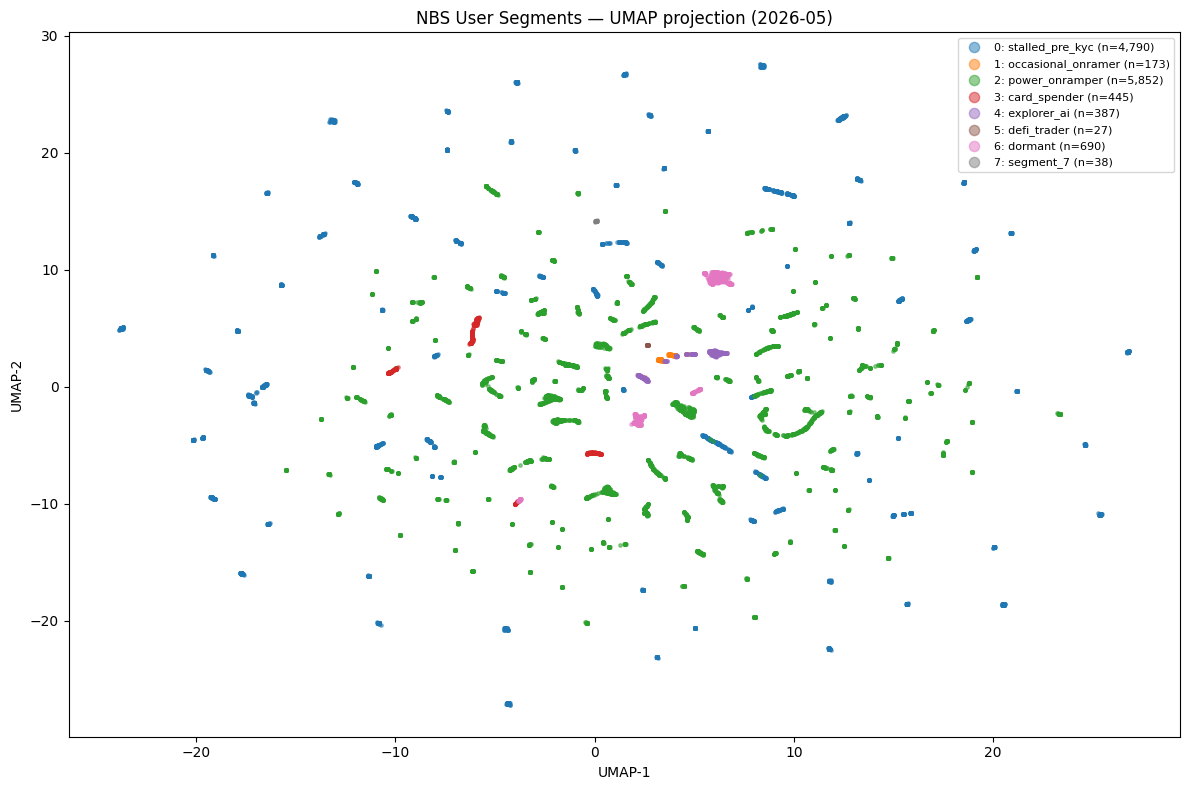

In [54]:
# ── UMAP 2D projection (visualization only — not used for clustering) ─────────
print("Running UMAP... (~1–2 min)")
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
X_2d = reducer.fit_transform(X_pca_clean)

df_clean["umap_x"] = X_2d[:, 0]
df_clean["umap_y"] = X_2d[:, 1]

fig, ax = plt.subplots(figsize=(12, 8))
palette = sns.color_palette("tab10", n_colors=BEST_K)
for seg_id, seg_name in SEGMENT_NAMES.items():
    mask = df_clean["cluster_id"] == seg_id
    ax.scatter(
        df_clean.loc[mask, "umap_x"],
        df_clean.loc[mask, "umap_y"],
        s=6, alpha=0.5, color=palette[seg_id],
        label=f"{seg_id}: {seg_name} (n={mask.sum():,})",
    )
ax.legend(loc="upper right", fontsize=8, markerscale=3)
ax.set(title=f"NBS User Segments — UMAP projection ({ANALYSIS_MONTH})",
       xlabel="UMAP-1", ylabel="UMAP-2")
plt.tight_layout()
plt.savefig(f"{PROCESSED_DIR}/crm_umap_{ANALYSIS_MONTH}.png", dpi=150)
plt.show()

### Visualização UMAP

UMAP (Uniform Manifold Approximation and Projection) reduz o espaço PCA (~8–12 dimensões) para 2D para visualização. **UMAP não é usado para clustering** — serve apenas para confirmar visualmente que os clusters estão separados no espaço de features.

**Interpretação:**

- Clusters bem separados no plano 2D → boa separabilidade, clusters coerentes
- Clusters sobrepostos no plano 2D → não necessariamente um problema (UMAP pode distorcer geometria em dimensões altas), mas vale inspecionar o heatmap para confirmar que as features médias são distintas
- Pontos isolados fora dos clusters principais → possíveis outliers que passaram pelo HDBSCAN (raro)

As cores no scatter plot correspondem aos `cluster_id` definidos pelo K-Means.

In [55]:
# ── Push notification message library ────────────────────────────────────────
# Three time-of-day slots: morning (07–09h BRT), afternoon (12–14h BRT),
#                          evening (19–21h BRT)
# Each segment has 2–3 message variants per slot.

MESSAGES = {
    "power_onramper": {
        "campaign_goal": "Cross-sell DeFi swaps and card. VIP framing — never discount.",
        "morning": [
            ("Alerta de taxa", "Comece o dia forte — seu BRL está pronto para converter na melhor taxa de hoje."),
        ],
        "afternoon": [
            ("Taxa favorável", "BRL/USDC está atraente agora. Converta em 60 segundos."),
        ],
        "evening": [
            ("USDC parado?", "Seu USDC está parado — que tal uma swap no Jupiter para fazer seu portfólio crescer?"),
        ],
    },
    "card_spender": {
        "campaign_goal": "Onramp cross-sell. They trust the card — remove friction to first conversion.",
        "morning": [
            ("Recarregue seu cartão", "Recarregue seu cartão NBS em 60 segundos — adicione BRL via PIX e converta na hora."),
        ],
        "afternoon": [
            ("Recarregue agora", "Seu cartão está pronto para usar. Complete com PIX e nunca fique sem saldo."),
        ],
        "evening": [
            ("Recarga rápida", "Recarga rápida antes de amanhã? PIX → USDC em menos de um minuto."),
        ],
    },
    "defi_trader": {
        "campaign_goal": "Deepen swap engagement. DeFi-native language only — no BRL/USDC pitch.",
        "morning": [
            ("Nova liquidez", "Nova liquidez no Jupiter — veja as melhores rotas de swap de hoje."),
        ],
        "afternoon": [
            ("Portfólio em movimento", "Seu portfólio está se movendo. Troque tokens sem taxas escondidas na NBS."),
        ],
        "evening": [
            ("DeFi não para", "DeFi não para. Viu uma oportunidade? Faça a swap agora."),
        ],
    },
    "occasional_onramer": {
        "campaign_goal": "Cross-sell depth — they onramp but stop there. Push the next product.",
        "morning": [
            ("USDC parado", "Seu USDC está parado — coloque-o para trabalhar com uma swap ou seu cartão NBS."),
        ],
        "afternoon": [
            ("Faz tempo...", "Faz tempo desde a sua última conversão. As taxas estão ótimas hoje."),
        ],
        "evening": [
            ("Próximo passo", "Mais um passo para desbloquear sua carteira NBS completa — faça uma swap ou solicite seu cartão."),
        ],
    },
    "explorer_ai": {
        "campaign_goal": "First conversion activation — they know the product, remove friction.",
        "morning": [
            ("Carteira pronta", "Sua carteira NBS está pronta — compre USDC com PIX e desbloqueie seu cartão hoje."),
        ],
        "afternoon": [
            ("Primeira conversão", "Você tem explorado a NBS — pronto para fazer sua primeira conversão BRL → USDC?"),
        ],
        "evening": [
            ("A um PIX de distância", "Sua conta está configurada. Uma transferência PIX e você está ativo."),
        ],
    },
    "stalled_pre_kyc": {
        "campaign_goal": "KYC funnel completion. Minimal copy, single CTA.",
        "delivery_rule": "Only send if device_tokens.is_active = TRUE.",
        "morning": [
            ("Verifique agora", "Verifique em 2 minutos — acesse BRL ↔ USDC em tempo real."),
        ],
        "afternoon": [
            ("Conta aguardando", "Sua conta NBS está esperando. Conclua a verificação para começar."),
        ],
        "evening": [
            ("2 minutos", "Leva 2 minutos. Depois é só usar a NBS."),
        ],
    },
    "dormant": {
        "campaign_goal": "Win-back. One send per quarter maximum.",
        "delivery_rule": "Skip if notification_read_rate = 0 over last 90 days.",
        "morning": [
            ("Novidades na NBS", "Temos novidades — a NBS ganhou recursos novos desde sua última visita."),
        ],
        "afternoon": [
            ("Saldo esperando", "Seu saldo está esperando. Entre e veja o que mudou."),
        ],
        "evening": [
            ("Ainda aqui", "Faz um tempo. Seu USDC ainda está aqui quando você quiser."),
        ],
    },
}

# Auto-populate generic fallback messages for any auto-padded segment_N clusters
# that didn't receive a named archetype. Replace copy once cluster is profiled.
_unnamed = set(SEGMENT_NAMES.values()) - set(MESSAGES.keys())
for _seg in _unnamed:
    MESSAGES[_seg] = {
        "campaign_goal": "Cluster não nomeado — revisar heatmap e atualizar copy.",
        "morning": [
            ("Novidade na NBS", "Sua conta NBS tem novidades. Abra o app e confira."),
        ],
        "afternoon": [
            ("NBS para você", "Explore tudo que a NBS tem a oferecer."),
        ],
        "evening": [
            ("Até amanhã", "Seu USDC está aqui quando você precisar."),
        ],
    }

if _unnamed:
    print(f"⚠  Segmentos sem copy personalizado (usar fallback): {sorted(_unnamed)}")
    print("   → Revise o heatmap, nomeie os clusters e atualize MESSAGES.")

assert set(MESSAGES.keys()) >= set(SEGMENT_NAMES.values()),     f"Segmentos sem mensagem: {set(SEGMENT_NAMES.values()) - set(MESSAGES.keys())}"

print("Message template library validated.")
for seg in sorted(SEGMENT_NAMES.values()):
    print(f"  {seg}: {MESSAGES[seg]['campaign_goal'][:60]}")

⚠  Segmentos sem copy personalizado (usar fallback): ['segment_7']
   → Revise o heatmap, nomeie os clusters e atualize MESSAGES.
Message template library validated.
  card_spender: Onramp cross-sell. They trust the card — remove friction to 
  defi_trader: Deepen swap engagement. DeFi-native language only — no BRL/U
  dormant: Win-back. One send per quarter maximum.
  explorer_ai: First conversion activation — they know the product, remove 
  occasional_onramer: Cross-sell depth — they onramp but stop there. Push the next
  power_onramper: Cross-sell DeFi swaps and card. VIP framing — never discount
  segment_7: Cluster não nomeado — revisar heatmap e atualizar copy.
  stalled_pre_kyc: KYC funnel completion. Minimal copy, single CTA.


In [ ]:
# ── Mark pushable users (left join — all clustered users kept) ───────────────
sql_pushable = text("""
    SELECT DISTINCT user_id
    FROM device_tokens
    WHERE is_active = TRUE
""")
df_pushable = pd.read_sql(sql_pushable, engine)
print(f"Users with active push token: {len(df_pushable):,}")

crm_export = (
    df_clean[["user_id", "cluster_id", "segment_name",
              "notification_read_rate", "days_since_last_active",
              "kyc_level", "is_outlier"]]
    .merge(df_pushable.assign(is_pushable=True), on="user_id", how="left")
)
crm_export["is_pushable"] = crm_export["is_pushable"].fillna(False).astype(bool)

# Delivery flag for dormant: backend should skip push if read_rate = 0
# (flag only — user stays in export for email/SMS fallback in Phase 2)
crm_export["skip_push"] = (
    (crm_export["segment_name"] == "dormant")
    & (crm_export["notification_read_rate"] == 0)
)

print(f"Total users in export:        {len(crm_export):,}")
print(f"  pushable (active token):    {crm_export['is_pushable'].sum():,}")
print(f"  no active token:            {(~crm_export['is_pushable']).sum():,}")
print(f"  dormant skip_push flag:     {crm_export['skip_push'].sum():,}")
print()
print(crm_export["segment_name"].value_counts())

In [ ]:
# ── Attach Portuguese message copy to each row ───────────────────────────────
def _pick_msg(segment: str, slot: str, messages: dict) -> tuple[str, str]:
    """Return (title, body) for segment + time slot."""
    data = messages.get(segment, messages.get("stalled_pre_kyc"))
    variants = data.get(slot, [("", "")])
    return variants[0]

for slot in ("morning", "afternoon", "evening"):
    crm_export[[f"title_{slot}", f"body_{slot}"]] = crm_export["segment_name"].apply(
        lambda seg: pd.Series(_pick_msg(seg, slot, MESSAGES))
    )

# ── KYC-level override (0 or 1 → verification CTA) ───────────────────────────
# kyc_level=2 means fully verified — those users get their segment copy.
KYC0_MESSAGES = {
    "morning":   ("Verifique agora",  "Verifique em 2 minutos — acesse BRL ↔ USDC em tempo real."),
    "afternoon": ("Conta aguardando", "Sua conta NBS está esperando. Conclua a verificação para começar."),
    "evening":   ("2 minutos",        "Leva 2 minutos. Depois é só usar a NBS."),
}
kyc_override_mask = crm_export["kyc_level"] <= 1
for slot, (title, body) in KYC0_MESSAGES.items():
    crm_export.loc[kyc_override_mask, f"title_{slot}"] = title
    crm_export.loc[kyc_override_mask, f"body_{slot}"]  = body

print(f"KYC level ≤1 users (verification CTA): {kyc_override_mask.sum():,}")

# ── Save CRM export CSV ───────────────────────────────────────────────────────
# Columns include delivery metadata so the backend can apply targeting rules:
#   is_pushable  — has active device token
#   skip_push    — dormant + zero notification engagement (Phase 2: use email/SMS)
#   is_outlier   — statistical outlier (extreme behavioral profile; treat with care)
#   kyc_level    — 0/1 = unverified (KYC CTA copy applied), 2 = fully verified
export_cols = [
    "user_id", "cluster_id", "segment_name", "kyc_level",
    "is_pushable", "skip_push", "is_outlier",
    "title_morning", "body_morning",
    "title_afternoon", "body_afternoon",
    "title_evening", "body_evening",
]
export_path = f"{PROCESSED_DIR}/crm_segments_{ANALYSIS_MONTH}.csv"
crm_export[export_cols].to_csv(export_path, index=False)
print(f"CRM export saved: {export_path} ({len(crm_export):,} rows)")
print()
print(crm_export[export_cols].head(3).to_string())

In [58]:
# ── Save model artifacts for incremental scoring ──────────────────────────────
joblib.dump(scaler,        f"{PROCESSED_DIR}/crm_scaler_{ANALYSIS_MONTH}.pkl")
joblib.dump(pca,           f"{PROCESSED_DIR}/crm_pca_{ANALYSIS_MONTH}.pkl")
joblib.dump(km_final,      f"{PROCESSED_DIR}/crm_kmeans_{ANALYSIS_MONTH}.pkl")
joblib.dump(SEGMENT_NAMES, f"{PROCESSED_DIR}/crm_segment_names_{ANALYSIS_MONTH}.pkl")

print("Saved artifacts:")
for suffix in ["scaler", "pca", "kmeans", "segment_names"]:
    path = f"{PROCESSED_DIR}/crm_{suffix}_{ANALYSIS_MONTH}.pkl"
    print(f"  {path}")

print("To score new users:")
print("  scaler = joblib.load(scaler_path)")
print("  pca    = joblib.load(pca_path)")
print("  km     = joblib.load(kmeans_path)")
print("  names  = joblib.load(segment_names_path)")
print("  X_new_pca = pca.transform(scaler.transform(X_new_log1p))")
print("  labels    = km.predict(X_new_pca)")

Saved artifacts:
  ../data/processed/crm_scaler_2026-05.pkl
  ../data/processed/crm_pca_2026-05.pkl
  ../data/processed/crm_kmeans_2026-05.pkl
  ../data/processed/crm_segment_names_2026-05.pkl
To score new users:
  scaler = joblib.load(scaler_path)
  pca    = joblib.load(pca_path)
  km     = joblib.load(kmeans_path)
  names  = joblib.load(segment_names_path)
  X_new_pca = pca.transform(scaler.transform(X_new_log1p))
  labels    = km.predict(X_new_pca)
